In [1]:
#Tabular Playground Series - Jun 2021
#Link Below
#https://www.kaggle.com/competitions/tabular-playground-series-jun-2021

#Lundquist Griffin griffin.lundquist@studio.unibo.it,
#McCallan Oliver, oliver.mccallan@studio.unibo.it
#Mendoza Alberto, alberto.mendozaperea@studio.unibo.it
#Simon Christopher, ronald.simon@studio.unibo.it
#Lanccetti Valerico, valerico.laccetti@studio.unibo.it




import warnings
warnings.filterwarnings('ignore') # uncomment this line to suppress warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
random_state = 42
train_size = 0.01 # train size chosen to have a few tousands of elements
cv = 5
np.random.seed(random_state) # this sets the random sequence. Setting only this the repeatability is guaranteed
                             # only if we re-execute the entire notebook
                             
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

print(f"Shape of the training data {df_train.shape}\nShape of the test data {df_test.shape}")

Shape of the training data (200000, 77)
Shape of the test data (100000, 76)


In [4]:
# show 10 random records
df_train.sample(10)

,id,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,target
119737,119737,0,0,15,0,0,0,0,0,11,...,0,0,1,0,0,0,1,0,0,Class_3
72272,72272,0,0,1,0,0,1,0,0,0,...,0,0,0,0,3,0,0,0,0,Class_6
158154,158154,0,0,0,0,0,0,0,0,0,...,0,0,0,3,0,0,0,0,0,Class_6
65426,65426,6,0,0,0,0,2,0,0,0,...,3,7,2,1,0,0,0,1,1,Class_8
30074,30074,0,0,0,0,0,0,0,0,0,...,0,0,0,3,0,0,0,0,0,Class_1
23677,23677,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,Class_2
134858,134858,0,0,0,0,0,0,0,0,0,...,0,0,0,2,0,1,0,0,0,Class_9
176418,176418,0,0,0,0,0,14,0,0,0,...,0,0,1,1,1,2,0,0,0,Class_2
132467,132467,0,2,1,3,1,0,0,7,8,...,0,1,0,0,20,18,1,0,1,Class_8
4082,4082,40,0,0,0,0,0,0,2,0,...,0,1,0,0,0,0,0,0,0,Class_5


In [5]:
# number of unique values
df_train.nunique().sort_values(ascending=False)

id            200000
feature_15       105
feature_60        99
feature_59        92
feature_73        91
               ...  
feature_18        21
feature_26        20
feature_30        18
feature_17        15
target             9
Length: 77, dtype: int64

In [6]:
classes = sorted(df_train["target"].unique().tolist())
classes

['Class_1',
 'Class_2',
 'Class_3',
 'Class_4',
 'Class_5',
 'Class_6',
 'Class_7',
 'Class_8',
 'Class_9']

In [7]:
# create X_full
X_full = df_train.drop(labels=["id", "target"], axis=1)
y = LabelEncoder().fit_transform(df_train["target"])

In [8]:
# show X_full
X_full.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74
0,0,0,6,1,0,0,0,0,7,0,...,3,0,0,0,0,0,0,2,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,1,0
2,0,0,0,0,0,1,0,3,0,0,...,8,0,0,0,0,1,0,0,0,0
3,0,0,7,0,1,5,2,2,0,1,...,0,0,4,0,2,2,0,4,3,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
model_lbls = ['dt' # decision tree
             #,'nb' # gaussian naive bayes
             ,'rf'   # random forest
             #,'lp'   # linear perceptron
             #,'svc'  # support vector
             #,'knn'  # k nearest neighbours
             #,'adb'  # adaboost
            ]

models = {
    'dt': {'name': 'Decision Tree       ',
           'estimator': DecisionTreeClassifier(random_state=random_state),
           'param': [{'max_depth': [*range(1,20)],'class_weight':[None,'balanced']}],
          },
    'nb': {'name': 'Gaussian Naive Bayes',
           'estimator': GaussianNB(),
           'param': [{'var_smoothing': [10**exp for exp in range(-3,-12,-1)]}]
          },
    'lp': {'name': 'Linear Perceptron   ',
           'estimator': Perceptron(random_state=random_state),
           'param': [{'early_stopping': [True,False],'class_weight':[None,'balanced']}],
          },
    'svc':{'name': 'Support Vector      ',
           'estimator': SVC(random_state=random_state),
           'param': [{'kernel': ['rbf'],
                    'gamma': [1e-3, 1e-4],
                    'C': [1, 10, 100],
                    },
                    {'kernel': ['linear'],
                     'C': [1, 10, 100],
                    },
                   ]
          },
    'knn':{'name': 'K Nearest Neighbor ',
           'estimator': KNeighborsClassifier(),
           'param': [{'n_neighbors': list(range(1,7))}]
       },
    'adb':{'name': 'AdaBoost           ',
           'estimator': AdaBoostClassifier(random_state=random_state),
           'param': [{'n_estimators':[20,30,40,50]
                     ,'learning_rate':[0.5,0.75,1,1.25,1.5]}]
          },
    'rf': {'name': 'Random forest       ',
           'estimator': RandomForestClassifier(random_state=random_state),
           'param': [{
                      # 'max_depth': [*range(4,30)]
                      'max_depth': [*range(4,30,4)]
                    #  ,'n_estimators':[*range(20,80,5)]
                     ,'n_estimators':[*range(10,30,5)]
                     ,'class_weight': [None,'balanced']
                      }]
          }

}


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
X_train_full, X_test_full, y_train, y_test = train_test_split(X_full, y, train_size=train_size, random_state=random_state)
print(f"There are {X_train_full.shape[0]} samples in the training dataset")
print(f"There are {X_test_full.shape[0]} samples in the testing dataset")
print(f"Each sample has {X_train_full.shape[1]} features")

There are 2000 samples in the training dataset
There are 198000 samples in the testing dataset
Each sample has 75 features


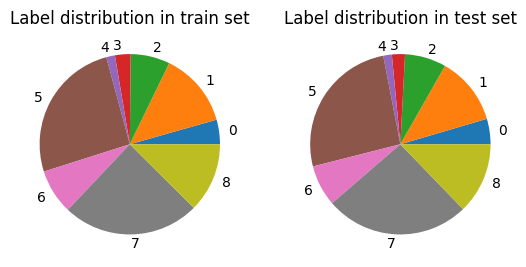

In [11]:
uniques_train = np.unique(y_train, return_counts=True)
uniques_test = np.unique(y_test, return_counts=True)

fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2)

ax1.set_title("Label distribution in train set")
ax1.pie(uniques_train[1], labels=uniques_train[0]);

ax2.set_title("Label distribution in test set")
ax2.pie(uniques_test[1], labels=uniques_test[0]);

In [12]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest

# select features 
k_best = 30  # Number of top features to select
selector = SelectKBest(mutual_info_classif, k=k_best)

X_train = selector.fit_transform(X_train_full, y_train)
X_test = selector.transform(X_test_full)

In [13]:
scorings = ['accuracy'
            # ,'precision_macro'
            # ,'recall_macro'
            ,'f1_macro'
            ]

In [14]:
clfs = []
results = pd.DataFrame(columns=['scoring','model','best_params','accuracy','precision_macro','recall_macro','f1_macro'])

# Grid search
for scoring in scorings:
    for m in model_lbls:
        clf = GridSearchCV(
            estimator=models[m]["estimator"],
            param_grid=models[m]["param"],
            cv=cv,
            scoring=scoring,
            n_jobs=-1   # to be quickier
        )
        clf.fit(X_train, y_train)
        clfs.append(clf)
        y_true, y_pred = y_test, clf.predict(X_test)
        cr = classification_report(y_true, y_pred, output_dict=True, zero_division=1)
        
        results.loc[len(results)] = [scoring,models[m]['name'],clf.best_params_
                                    # ,(clf.cv_results_['mean_fit_time'].sum()+clf.cv_results_['mean_score_time'].sum())*n_splits
                                    ,cr['accuracy']
                                    ,cr['macro avg']['precision']
                                    ,cr['macro avg']['recall']
                                    ,cr['macro avg']['f1-score']]

In [15]:
for score in scorings:
    scoring_filter = score
    display(
        results[results["scoring"]==scoring_filter]\
        .sort_values(by=scoring_filter,ascending=False)\
        .drop('scoring',axis=1)\
        .style.format(precision=3)\
        .set_caption('Results for scoring "{}"'.format(scoring_filter))
    )

,model,best_params,accuracy,precision_macro,recall_macro,f1_macro
1,Random forest,"{'class_weight': None, 'max_depth': 4, 'n_estimators': 25}",0.335,0.671,0.174,0.134
0,Decision Tree,"{'class_weight': None, 'max_depth': 2}",0.312,0.770,0.164,0.124


,model,best_params,accuracy,precision_macro,recall_macro,f1_macro
3,Random forest,"{'class_weight': 'balanced', 'max_depth': 8, 'n_estimators': 10}",0.246,0.155,0.166,0.154
2,Decision Tree,"{'class_weight': None, 'max_depth': 16}",0.235,0.142,0.149,0.143


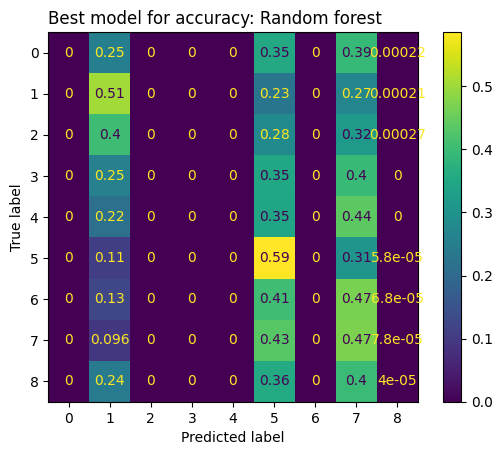

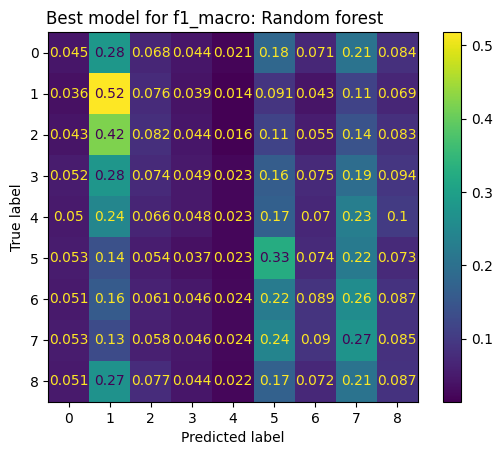

In [16]:
best_clf = {}
for score in scorings:
    scoring_filter = score
    best_model = results[results["scoring"]==scoring_filter]\
        .sort_values(by=scoring,ascending=False)\
        .head(1)
    best_clf[score]=clfs[best_model.index[0]]
    
    model_name = best_model['model'].iloc[0]
    title = f"Best model for {score}: {model_name}"
    cm = ConfusionMatrixDisplay.from_estimator(
        X=X_test, 
        y=y_test, 
        estimator = best_clf[score], 
        normalize='true'
    )
    cm.ax_.set_title(title)
plt.show()

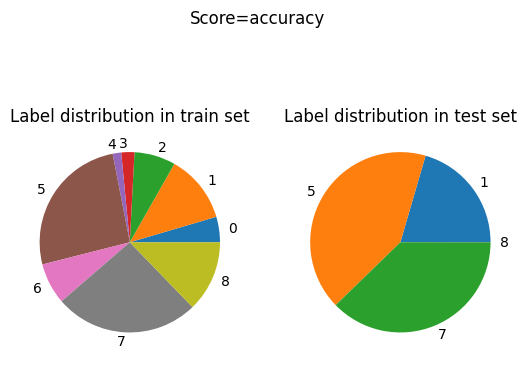

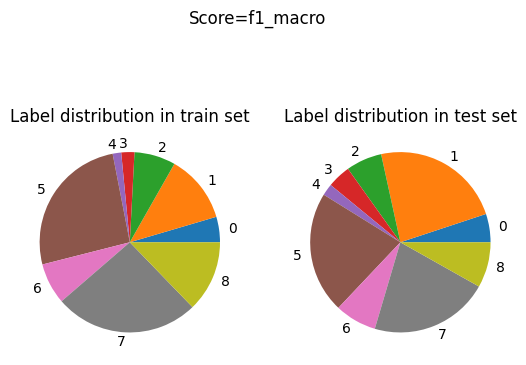

In [ ]:
# final test with best model trained on all (train) data
X_full = df_test.drop(labels=["id"], axis=1)

# select features 
X = selector.transform(X_full)

for score in scorings:
    classifier = best_clf[score]
    y_pred = classifier.predict(X)
    
    uniques_train = np.unique(y, return_counts=True)
    uniques_test = np.unique(y_pred, return_counts=True)

    fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2)
    fig.suptitle(f"Score={score}")

    ax1.set_title("Label distribution in train set")
    ax1.pie(uniques_train[1], labels=uniques_train[0]);

    ax2.set_title("Label distribution in test set")
    ax2.pie(uniques_test[1], labels=uniques_test[0]);